## Import libraries

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import json

import sys, os
from rctorch.utils import minmax_transform

from scipy.signal import find_peaks

## Preparations for Lorenz Attractor

In [2]:
def load_tensor(save_path:str, name:str):
    file_name = os.path.join(save_path, name + ".pt")
    tensor = torch.load(os.path.join(save_path, file_name))
    print(f"Loaded {file_name} from {save_path}")
    return tensor

In [3]:
def choose_path(base_path:str):
    if not os.path.exists(base_path):
        print(f"Path {base_path} does not exist.")
        return None
    print(f"Using path: {base_path}")
    
    dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    dirs = [d for d in dirs if os.path.exists(os.path.join(base_path, d, "params.json"))]
    dirs.sort()  # Sort directories to have a consistent order
    if not dirs:
        print("No directories with params.json found in the specified path.")
        return None
    print("Available directories:")
    for i, d in enumerate(dirs):
        print(f"{i}: {os.path.basename(d)}")
    choice = input("Enter the number of the directory you want to use: ")
    try:
        choice = int(choice)
        if 0 <= choice < len(dirs):
            selected_path = os.path.join(base_path, dirs[choice])
            print(f"Selected path: {selected_path}")
            return selected_path
        else:
            print("Invalid choice. Please enter a valid number.")
            return None
    except ValueError:
        print("Invalid input. Please enter a number.")
        return None

def load_params_from_path(save_path:str):
    # Load parameters encoded into the directory name
    if not os.path.exists(save_path):
        print(f"Path {save_path} does not exist.")
    
        return None
    print(f"Using path: {save_path}")
    # Extract parameters from the directory name
    params = json.load(open(os.path.join(save_path, "params.json"), "r"))
    print("Loaded parameters:", params)
    # Load tensors from the directory
    data = {}
    for file_name in os.listdir(save_path):
        if file_name.endswith(".pt"):
            key = file_name[:-3]  # Remove the '.pt' extension
            data[key] = load_tensor(save_path, key)
    return params, data    

In [5]:
path = choose_path(os.path.join(os.getcwd(), "results", "conductance"
                                ))

Using path: /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance
Available directories:
0: Q_100_gbar_15_l_1.0_Ne_4000_Ni_1000
1: Q_200_gbar_25_l_1.0_Ne_4000_Ni_1000
2: Q_250_gbar_25_l_1.0_Ne_4000_Ni_1000
3: Q_300_gbar_25_l_1.0_Ne_4000_Ni_1000
4: Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000
Selected path: /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance/Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000


In [6]:
params, data = load_params_from_path(path)

Using path: /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance/Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000
Loaded parameters: {'Q': 400, 'gbar': 5, 'delta': 1.0, 'sparse': 0.01, 'Ie': 70, 'Ii': 70, 'NE': 4000, 'NI': 1000, 'memory_length': 5000, 'rls_start': 500, 'rls_stop': 10000.0, 'rls_step': 20, 'ff_coeff': 1, 'T': 20000, 'dt': 0.1, 'seed': 1}
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance/Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000/weights.pt from /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance/Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance/Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000/s_rec_train.pt from /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance/Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000
Loaded /home/ali/Code/research/ml_force_research/morris_lecar/results/conductance/Q_400_gbar_5_l_1.0_Ne_4000_Ni_1000/v_rec_train.pt from /home/ali

In [7]:
# Initialize parameters
for key, value in params.items():
    print(f"{key}: {value}")
    exec(f"{key} = {value}")

Q: 400
gbar: 5
delta: 1.0
sparse: 0.01
Ie: 70
Ii: 70
NE: 4000
NI: 1000
memory_length: 5000
rls_start: 500
rls_stop: 10000.0
rls_step: 20
ff_coeff: 1
T: 20000
dt: 0.1
seed: 1


In [8]:
# Iinitialize data
ml_w = data['weights']
s_rec_train = data["s_rec_train"]
v_rec_train = data["v_rec_train"]
n_rec_train = data["n_rec_train"]
xhat_rec_train = data["xhat_rec_train"]
dec_rec_train = data["dec_rec_train"]
sup = data["sup_tensor"].cpu().numpy()

s_rec_test = data["s_rec_test"]
v_rec_test = data["v_rec_test"]
n_rec_test = data["n_rec_test"]
x_hat_rec =  data["x_hat_rec"]

In [9]:
save_path = os.path.join(os.getcwd(), "results", "figures", "conductance"
                         )
if not os.path.exists(save_path):
    os.makedirs(save_path)


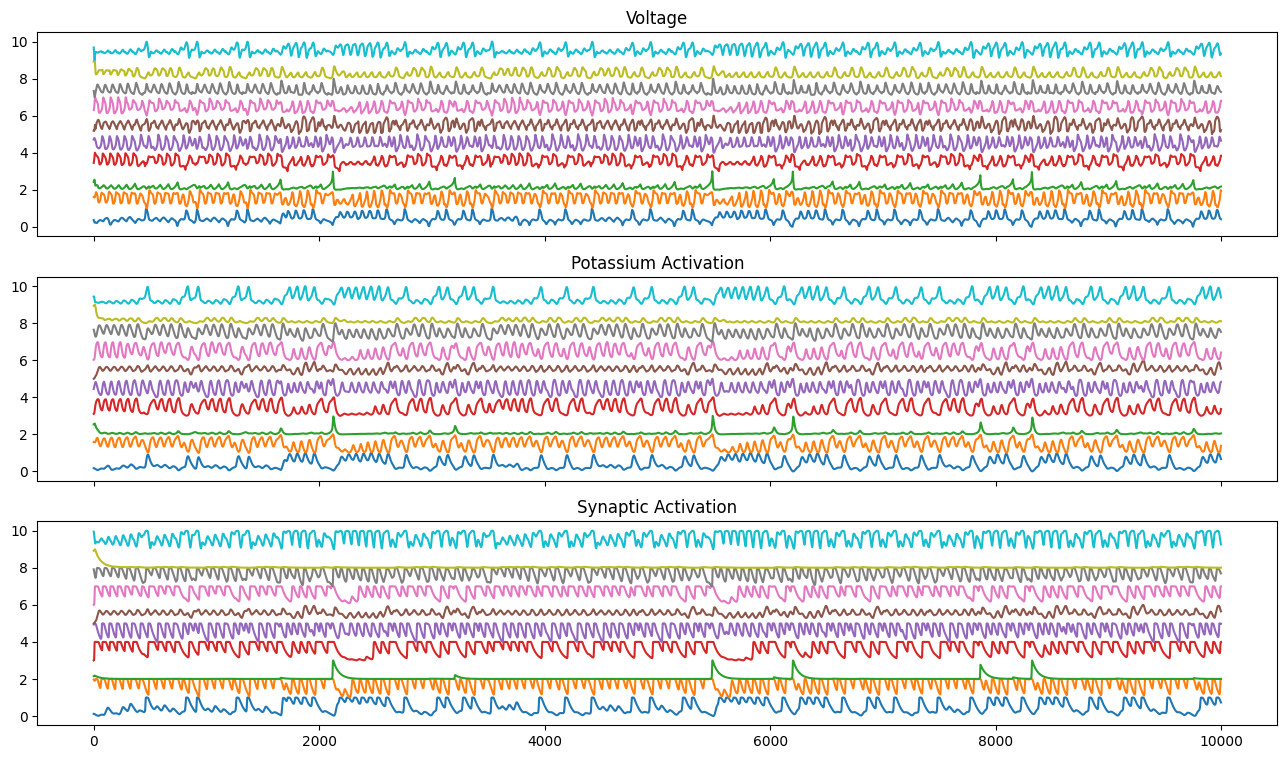

In [10]:
nt_train = v_rec_train.shape[0]
n_neurons = v_rec_train.shape[1]

t_train = np.arange(nt_train) * dt

fig, ax = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for i in range(n_neurons):
    ax[0].plot(t_train, minmax_transform(v_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[1].plot(t_train, minmax_transform(n_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
    ax[2].plot(t_train, minmax_transform(s_rec_train[:, i].cpu().numpy().reshape(-1, 1))+i)
ax[0].set_title('Voltage')
ax[1].set_title('Potassium Activation')
ax[2].set_title('Synaptic Activation')
plt.show()

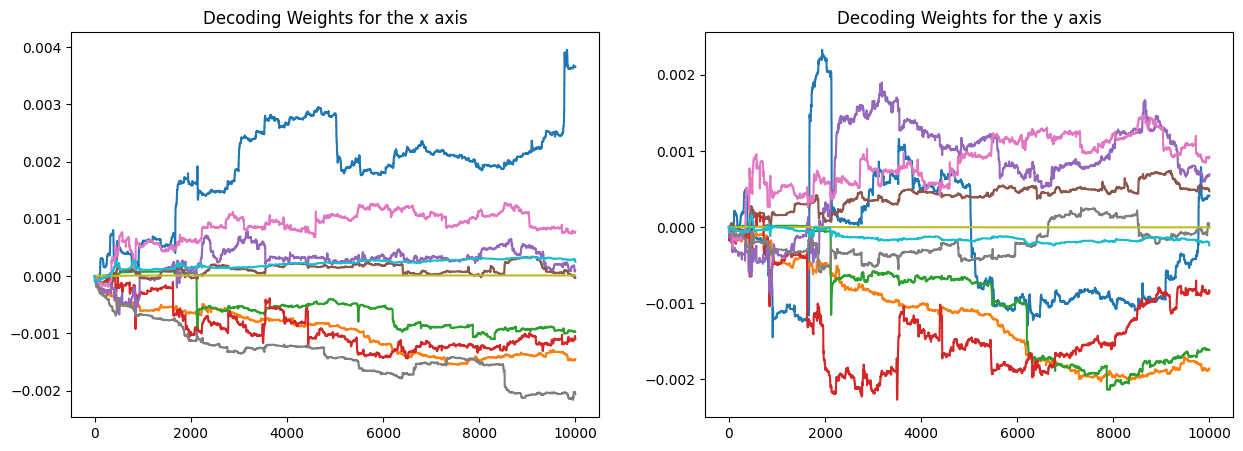

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
ax[0].plot(t_train, dec_rec_train[:, :, 0].cpu().numpy())
ax[0].set_title('Decoding Weights for the x axis')
ax[1].plot(t_train, dec_rec_train[:, :, 1].cpu().numpy())
ax[1].set_title('Decoding Weights for the y axis')
plt.show()

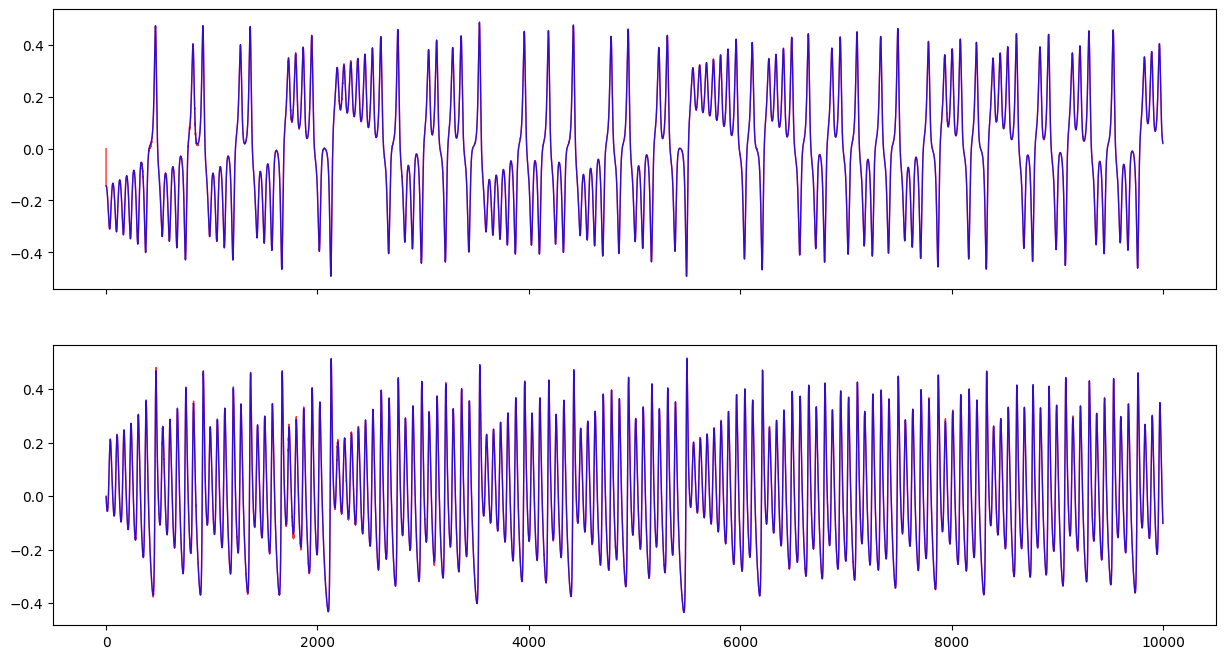

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax[0].plot(t_train, xhat_rec_train[:, 0].cpu().numpy(), 'r-', lw=1, alpha=.8)
ax[0].plot(t_train, sup[:nt_train, 0], 'b-', lw=1, alpha=.8)
ax[1].plot(t_train, xhat_rec_train[:, 2].cpu().numpy(), 'r-', lw=1, alpha=.8)
ax[1].plot(t_train, sup[:nt_train, 2], 'b-',  lw=1, alpha=.8)
plt.show()

In [13]:
extension = "pdf"

In [15]:
mpl.rcParams["axes.formatter.use_mathtext"] = True
mpl.rcParams["mathtext.fontset"] = "cm"
mpl.rcParams["font.family"] = "Nimbus Roman"
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.labelsize"] = 18
mpl.rcParams["font.style"] = "normal"
mpl.rcParams["legend.fontsize"] = 12
mpl.rcParams["legend.title_fontsize"] = 12
# mpl.rcParams["text.usetex"] = False

In [16]:
from plot_styles import set_thesis_style

set_thesis_style()

In [15]:
mpl.rcParams['font.family']

['Nimbus Roman']

In [17]:
nt_test = s_rec_test.shape[0]
t_test = np.arange(nt_test) * dt + rls_stop
n_neurons = s_rec_test.shape[1]

In [18]:
hists = []
for axis in range(sup.shape[1]):
    sup_hist, bins = np.histogram(sup[-nt_test:, axis], bins=200, density=True)
    output_hist, bins = np.histogram(x_hat_rec[:, axis].cpu().numpy(), bins=bins, density=True)
    hists.append((sup_hist, output_hist, bins))

# KL Divergence
kl_divs = []
for i in range(len(hists)):
    sup_hist, output_hist, _ = hists[i]
    sup_hist = sup_hist / np.sum(sup_hist)  # normalize
    output_hist = output_hist / np.sum(output_hist) # normalize
    # Mask zeros
    sup_hist = np.where(sup_hist == 0, 1e-10, sup_hist)
    output_hist = np.where(output_hist == 0, 1e-10, output_hist)
    # KL Divergence
    kl_div = np.sum(sup_hist * np.log(sup_hist / output_hist))
    print(f"KL Divergence for axis {i}: {kl_div}")
    kl_divs.append(kl_div)

KL Divergence for axis 0: 0.051329495302861516
KL Divergence for axis 1: 0.06227242198491796
KL Divergence for axis 2: 0.06109458016750849


In [19]:
total_loss = np.sum(kl_divs)
total_loss.item()

0.17469649745528798

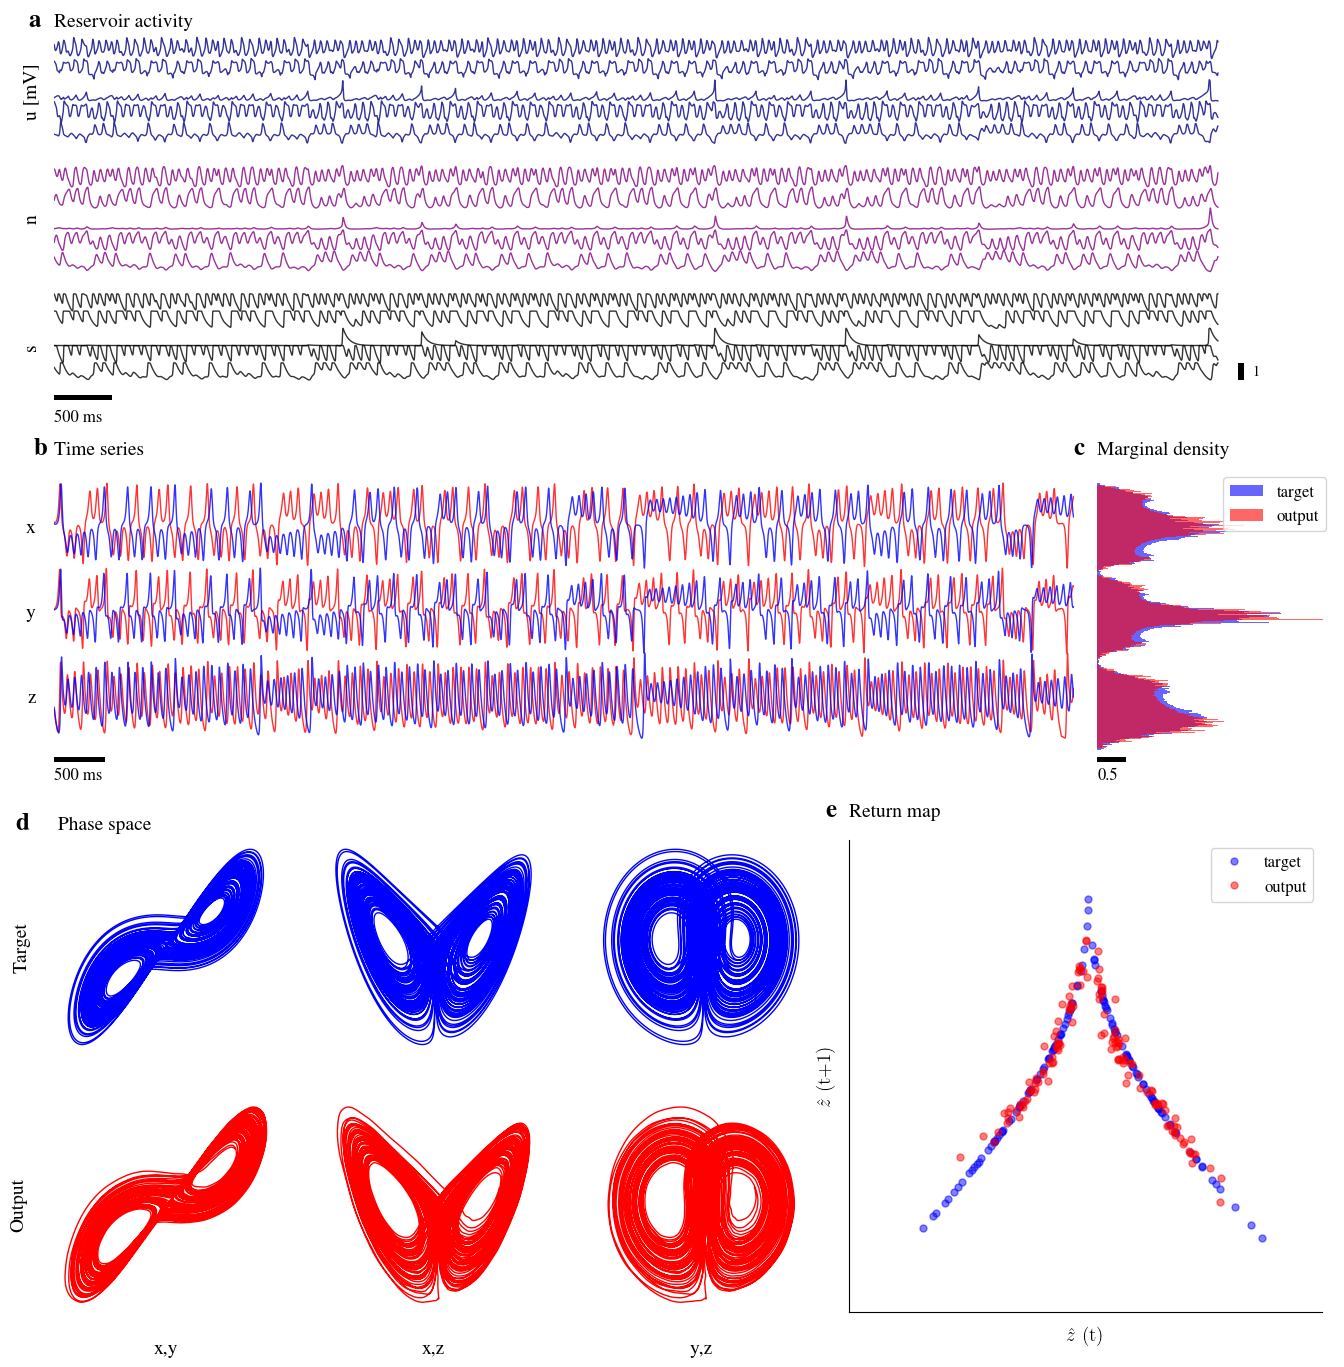

In [28]:
ax_names = ['x', 'y', 'z']

alpha = .8
density_alpha = 0.6
lw = 1.0

fig = plt.figure(figsize=(16, 16))
# fig.set_layout_engine('constrained')
gc = fig.add_gridspec(nrows=6 , ncols=5, hspace=0.4, wspace=0.1, height_ratios=[.4, .4, .4, 1.5, 1, 1],
                     width_ratios=[1, 1, 1, 1, 1], left=0.1, right=0.9, top=0.9, bottom=0.1)


# =================== Activity plots =========================
# activity_fig = fig.add_subfigure(gc[0, :])
# activity_ax = fig.subplots(3, 1, sharex=True)
gc_activity = gc[0:3, :].subgridspec(3, 1, hspace=0.1)
u_ax = fig.add_subplot(gc_activity[0, :], label='u_ax')
n_ax = fig.add_subplot(gc_activity[1, :], label='n_ax', sharex=u_ax)
s_ax = fig.add_subplot(gc_activity[2, :], label='s_ax', sharex=u_ax)


n_neurons = 5

for i in range(n_neurons):
    u_ax.plot(
        t_test, 
        minmax_transform(v_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i, 
        color='navy', ls='-', lw=lw, alpha=alpha
        )
    n_ax.plot(
        t_test, 
        minmax_transform(n_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i, 
        color='purple', ls='-', lw=lw, alpha=alpha
        )
    s_ax.plot(
        t_test, 
        minmax_transform(s_rec_test[:, i].cpu().numpy().reshape(-1, 1))+i, 
        color='black', ls='-', lw=lw, alpha=alpha
        )
# activity_ax[0].set_xlim([t_test[0], t_test[-1]])
# activity_ax[1].set_xlim([t_test[0], t_test[-1]])
u_ax.set_xlim([t_test[0], t_test[-1] + 1000])  # Extend x-axis for better visibility
time_bar_len = 500  # Length of the time bar in ms
s_ax.barh(y=-1, left=t_test[0], width=time_bar_len, height=.3, color='black')
s_ax.text(x=0.0, y=-0.1, s=f'{time_bar_len} ms', ha='left', va='center', transform=s_ax.transAxes,
                    fontsize=12, color='black')

u_ax.set_ylabel('u [mV]', rotation=90, labelpad=10)
u_ax.set_frame_on(False)
u_ax.set_xticks([])
u_ax.set_yticks([])
n_ax.set_ylabel('n', rotation=90, labelpad=10)
n_ax.set_yticks([])
n_ax.set_xticks([])
n_ax.set_frame_on(False)
s_ax.set_ylabel('s', rotation=90, labelpad=10)
s_ax.set_yticks([])
s_ax.set_xticks([])
s_ax.set_frame_on(False)
s_ax.bar(x=s_ax.get_xlim()[1] - 800, height=1, width=50, color='black', bottom=0.0)
s_ax.text(x=s_ax.get_xlim()[1] - 700, y=0.3, s="1")


# ================= Final Timeseries plot with density hbar plots =========================
# timeseries_fig = fig.add_subfigure(gc[1, 0])
# gc_timeseries = timeseries_fig.add_gridspec(1, 2, width_ratios=[0.8, 0.2], wspace=0.02)
# Density plots
hists_ax = fig.add_subplot(gc[3, -1], label='hists_ax') # Row 4, last column
# Plot histograms as horizontal bar plots
for axis in range(sup.shape[1]):
    sup_hist, output_hist, bins = hists[axis]
    # bins = (bins[:-1] + bins[1:]) / 2  # center of the bins
    bins_normalized = minmax_transform(bins.reshape(-1, 1)).reshape(-1) - axis
    width = bins_normalized[1] - bins_normalized[0]
    # Plot histograms as horizontal bar plots
    _, _, target_line = hists_ax.hist(
        bins_normalized[:-1], weights=sup_hist, bins=bins_normalized, 
        orientation='horizontal',
        label="target", color='b', alpha=density_alpha, density=True
        )
    _, _, output_line = hists_ax.hist(
        bins_normalized[:-1], weights=output_hist, bins=bins_normalized, 
        orientation='horizontal',
        label="output", color='r', alpha=density_alpha, density=True
        )
time_bar_len = .5  # Length of the time bar in ms
hists_ax.barh(y=-axis-0.1, left=0, width=time_bar_len, height=.05, color='black')
hists_ax.text(x=0.0, y=-0.0, s=f'{time_bar_len}', ha='left', va='center', transform=hists_ax.transAxes,
                    fontsize=12, color='black')

# Disable frame and ticks
hists_ax.set_frame_on(False)
hists_ax.set_yticks([])
hists_ax.set_xticks([])
# Set legend
hists_ax.legend(handles=[target_line[0], output_line[0]], loc='upper right')

# Plot timeseries
timeseries_ax = fig.add_subplot(gc[3, :-1], label='timeseries_ax')  # Row 4, all columns except the last one

for i_ax in range(sup.shape[1]):
    out_line = timeseries_ax.plot(
        t_test, 
        minmax_transform(x_hat_rec[:, i_ax].cpu().numpy().reshape(-1, 1)) - i_ax,
        'r-', lw=lw, alpha=alpha, label='output'
        )
    sup_line = timeseries_ax.plot(
        t_test, 
        minmax_transform(sup[-nt_test:, i_ax].reshape(-1, 1)) - i_ax,
        'b-', lw=lw, alpha=alpha, label='target'
        )
timeseries_ax.set_xlim([t_test[0], t_test[-1]])  # Extend x-axis for better visibility
timeseries_ax.set_yticks(ticks=[0.5, -0.5, -1.5], labels=ax_names)
timeseries_ax.tick_params(axis='y', pad=10, left=False)
timeseries_ax.set_xticks([])
timeseries_ax.set_frame_on(False)

# timeseries_ax.legend(handles=[out_line[0], sup_line[0]], loc='upper right')
time_bar_len = 500  # Length of the time bar in ms
timeseries_ax.barh(y=min(timeseries_ax.get_ylim()) - 0.1, left=t_test[0], width=time_bar_len, height=.05, color='black')
timeseries_ax.text(x=0.0, y=-0.0, s=f'{time_bar_len} ms', ha='left', va='center', transform=timeseries_ax.transAxes,
                    fontsize=12, color='black')

# timeseries_ax.set_xlabel('Time [ms]')

# ==================== Phase Space plots and return map =========================
# phase_fig = fig.add_subfigure(gc[5:7, :-2]) # row 5, 6, all except the last 2 columns

phase_gc = gc[4:6, :3].subgridspec(2, 3)
phase_ax = np.array([
    [fig.add_subplot(phase_gc[i, j], label=f"phase_ax_{i}_{j}", aspect='equal') for j in range(3)] for i in range(2)
    ])

combinations = [(0, 1), (0, 2), (1, 2)]
for i in range(sup.shape[1]):
    phase_ax[0, i].plot(
        sup[-nt_test:, combinations[i][0]], 
        sup[-nt_test:, combinations[i][1]], 
        'b-', lw=lw, label="target"
        )
    phase_ax[1, i].plot(
        x_hat_rec[:, combinations[i][0]].cpu().numpy(), 
        x_hat_rec[:, combinations[i][1]].cpu().numpy(), 
        'r-', lw=lw, label="output"
        )
    phase_ax[1, i].set_xlabel(f"{','.join([ax_names[combinations[i][0]], ax_names[combinations[i][1]]])}", labelpad=20)

for ax in phase_ax.ravel():
    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect(aspect='equal', anchor='C')

phase_ax[0, 0].set_ylabel('Target', labelpad=20)
phase_ax[1, 0].set_ylabel('Output', labelpad=20)
fig.align_xlabels(phase_ax[1, :])  # Align x-labels of the second row


# return_map_fig = phase_fig.add_subfigure(gc[2, 1])
return_map_ax = fig.add_subplot(gc[-2:, -2:], label='return_map_ax')  # Last row, last two columns
return_map_ax.set_aspect(aspect=1, 
                         anchor='C')
return_map_ax.transScale = mpl.transforms.Affine2D().scale(.8, .8)

# Plot return map for the first two axes
z = sup[-nt_test:, 2]
z_hat = x_hat_rec[:, 2].cpu().numpy()

dist = 500

peaks = z[find_peaks(z, distance=dist)[0]]
# peaks = peaks[peaks > 0]
peaks_hat = z_hat[find_peaks(z_hat, distance=dist)[0]]
# peaks_hat = peaks_hat[peaks_hat > 0]

ms = 5
alpha = .5
target = return_map_ax.plot(peaks[:-1], peaks[1:], 'bo', ms=ms, label="target", alpha=alpha)
output = return_map_ax.plot(peaks_hat[:-1], peaks_hat[1:], 'ro', ms=ms, label="output", alpha=alpha)

return_map_ax.set_xticks([])
return_map_ax.set_yticks([])
return_map_ax.legend(loc='upper right', handles=[target[0], output[0]])
return_map_ax.set_xlabel(r"$\hat{z}$ (t)", labelpad=10, usetex=True)
return_map_ax.set_ylabel(r"$\hat{z}$ (t+1)", labelpad=10, usetex=True)
# return_map_ax.


# fig.align_ylabels(phase_ax[:, 0], timeseries_ax, activity_ax)
pad = 0
y =  1.05  # y position for the titles

label_font_size = 18

activity_title = u_ax.set_title(label='Reservoir activity', loc='left', pad=pad, y=y)
activity_label = u_ax.text(
    x=-0.02, y=y, s="a", fontsize=label_font_size, fontweight='bold', transform=u_ax.transAxes
    )

lorenz_title = timeseries_ax.set_title(label='Time series', loc='left', pad=pad,  y=y)
lorenz_label = timeseries_ax.text(
    x=-0.02, y=y, s="b", fontsize=label_font_size, fontweight='bold', transform=timeseries_ax.transAxes
    )

density_title = hists_ax.set_title(label='Marginal density', loc='left', pad=pad, y=y)
density_label = hists_ax.text(
    x=-0.1, y=y, s="c", fontsize=label_font_size, fontweight='bold', transform=hists_ax.transAxes
    )

phase_title = phase_ax[0, 0].set_title(label='Phase space', loc='left', pad=pad, y=y)
phase_label = phase_ax[0, 0].text(
    x=-0.2, y=y, s="d", fontsize=label_font_size, fontweight='bold', transform=phase_ax[0, 0].transAxes
    )

return_map_title = return_map_ax.set_title(label='Return map', loc='left', pad=pad, y=y)
return_map_label = return_map_ax.text(
    x=-0.05, y=y, s="e", fontsize=label_font_size, fontweight='bold', transform=return_map_ax.transAxes
    )
return_map_ax.set_xlim(0.1, .6)
return_map_ax.set_ylim(0.1, .6)
return_map_ax.set_aspect(aspect=1, anchor='C')

fig.align_titles([phase_ax[0, 0], return_map_ax])


fig.savefig(os.path.join(save_path, f"reservoir_activity." + extension), dpi=300, pad_inches=0.1)
plt.show(fig)

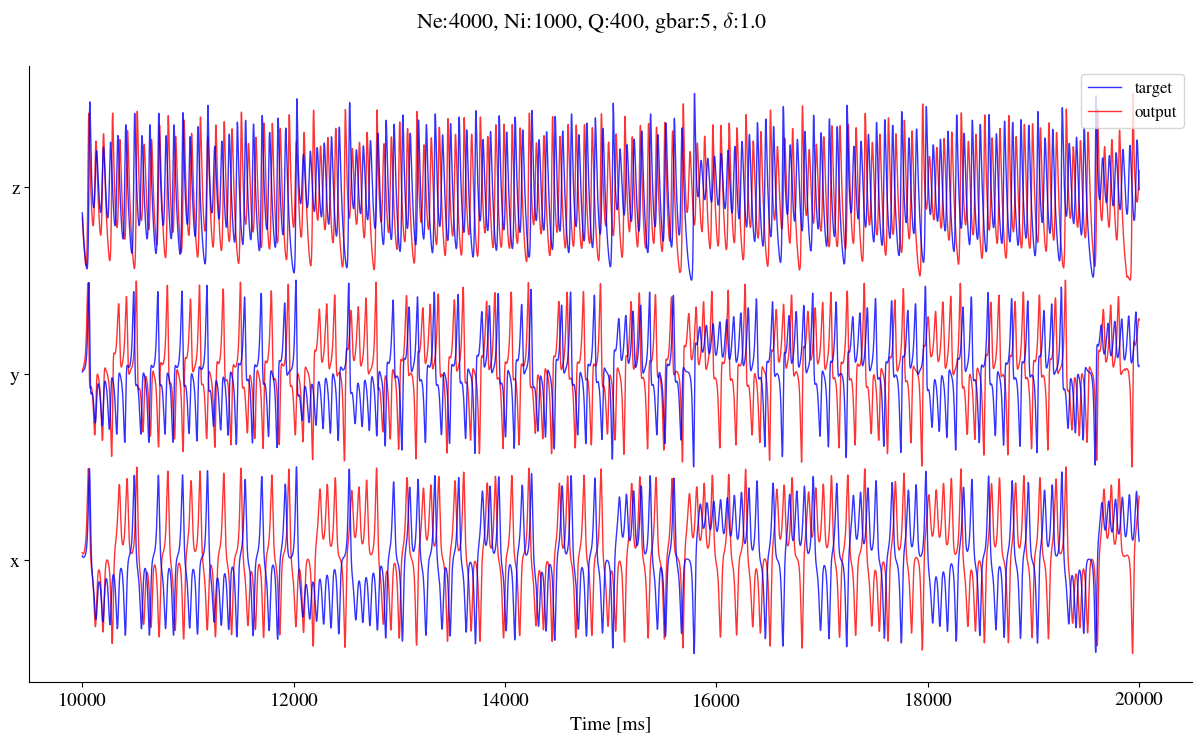

In [22]:
alpha = .8
N = NE + NI
fig, ax = plt.subplots(1, 1, figsize=(15, 8), sharex=True)
for i_ax in range(sup.shape[1]):
    out_line = ax.plot(
        t_test, 
        minmax_transform(x_hat_rec[:, i_ax].cpu().numpy().reshape(-1, 1)) + i_ax,
        'r-', lw=1, alpha=alpha, label='output'
        )
    sup_line = ax.plot(
        t_test, 
        minmax_transform(sup[-nt_test:, i_ax].reshape(-1, 1)) + i_ax,
        'b-', lw=1, alpha=alpha, label='target'
        )

ax.legend(handles=[sup_line[0], out_line[0]], loc='upper right')
ax.set_yticks(ticks=[.5, 1.5, 2.5], labels=['x', 'y', 'z'])
plt.xlabel('Time [ms]')

plt.suptitle(fr"Ne:{NE}, Ni:{NI}, Q:{Q}, gbar:{gbar}, $\delta$:{delta}", y=0.95, fontsize=16)
# plt.savefig(os.path.join(save_path, f"N_{N}_ff_{ff_coeff}_timeseries." + extension), dpi=300, bbox_inches='tight')
plt.show()

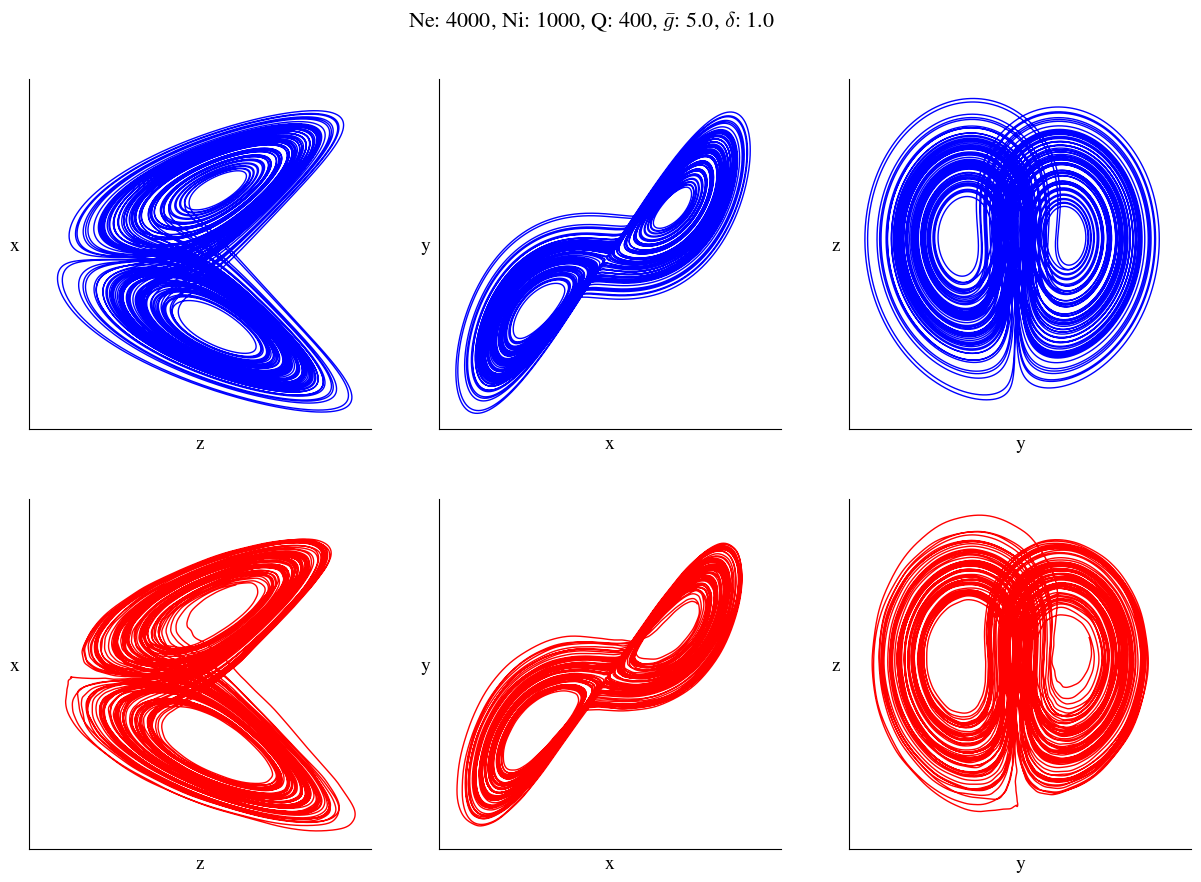

In [23]:
fig, ax = plt.subplots(ncols=sup.shape[1], nrows=2, figsize=(15, 10), sharex=True, sharey=True)

ax_names = ["x", "y", "z"]
for i in range(sup.shape[1]):
    ax[0, i].plot(sup[-nt_test:, i-1], sup[-nt_test:, i], 'b-', lw=1, label="sup")
    ax[1, i].plot(x_hat_rec[:, i-1].cpu().numpy(), x_hat_rec[:, i].cpu().numpy(), 'r-', lw=1, label="out")

    ax[0, i].set_xlabel(f"{ax_names[i-1]}")
    ax[1, i].set_xlabel(f"{ax_names[i-1]}")
    
    ax[0, i].set_ylabel(f"{ax_names[i]}", rotation=0, labelpad=10)
    ax[1, i].set_ylabel(f"{ax_names[i]}", rotation=0, labelpad=10)

for axis in ax.ravel():
    axis.set_xticks([])
    axis.set_yticks([])

# plt.legend()
plt.suptitle(r"Ne: %d, Ni: %d, Q: %d, $\bar{g}$: %.1f, $\delta$: %.1f" % (NE, NI, Q, gbar, delta), y=0.95, fontsize=16)
# plt.savefig(os.path.join(save_path, f"N_{N}_ff_{ff_coeff}_phase_space." + extension), dpi=300, bbox_inches='tight')
plt.show(fig)

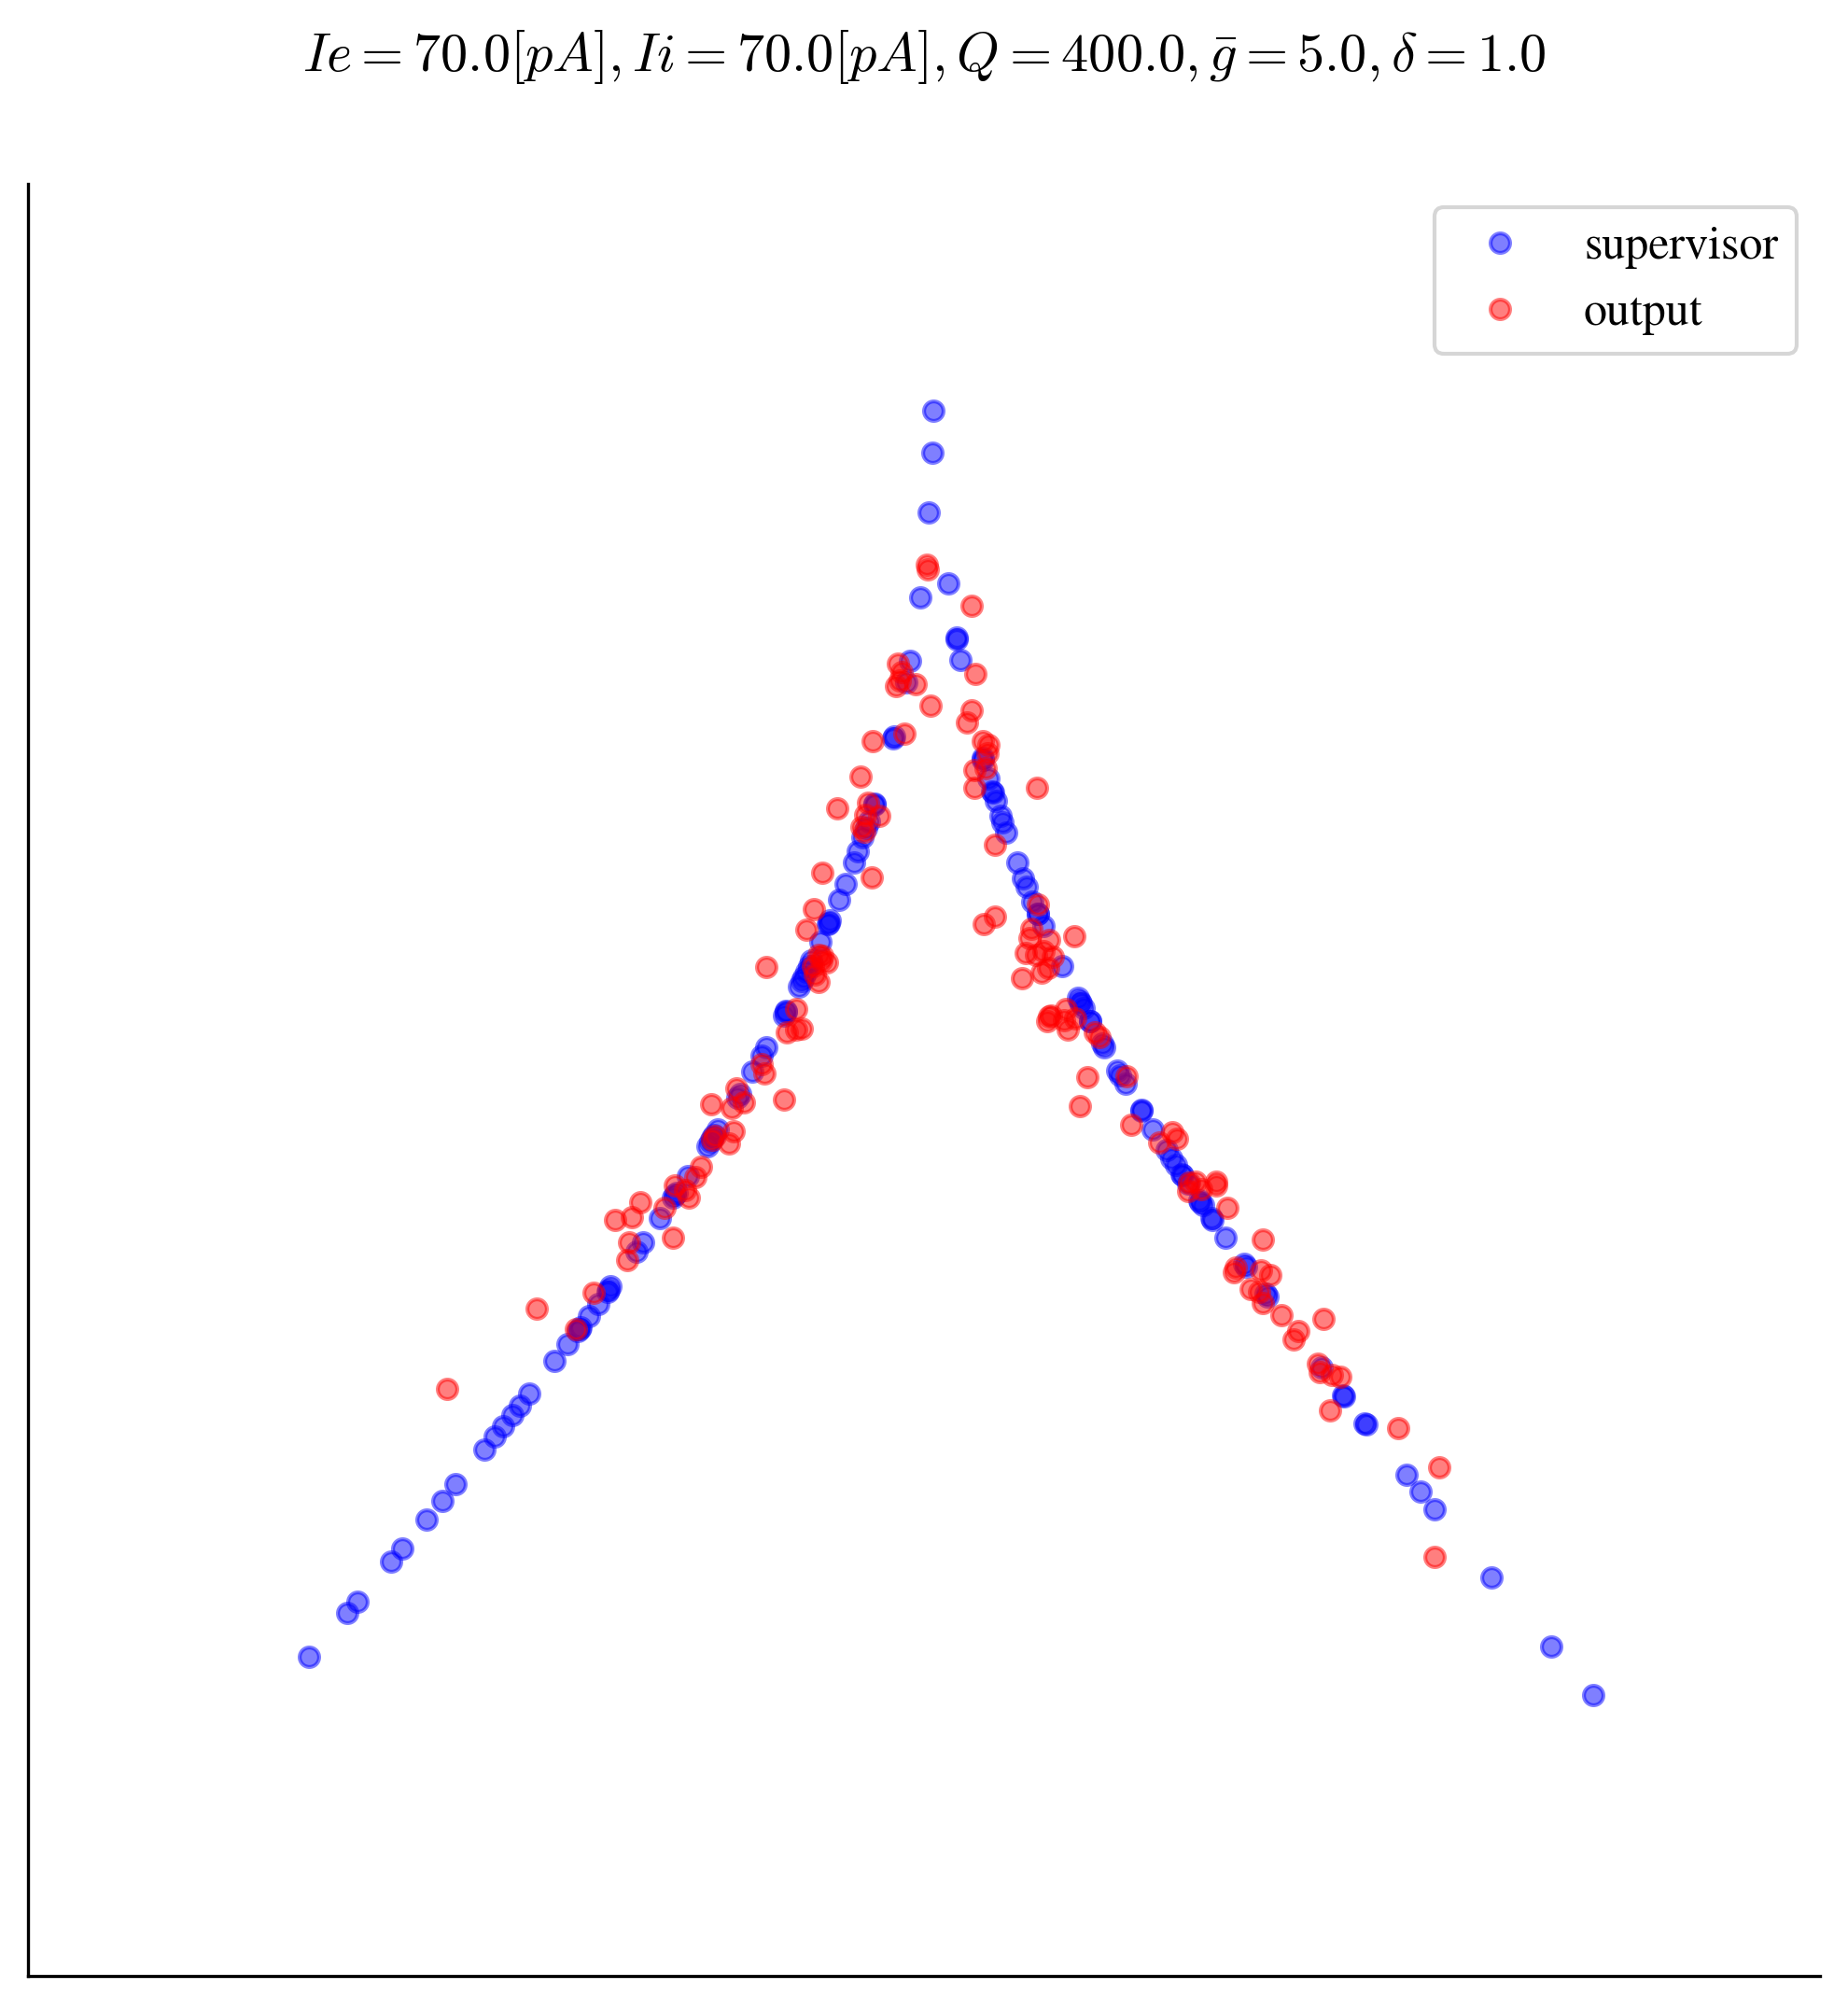

In [26]:
z = sup[-nt_test:, 2]
z_hat = x_hat_rec[:, 2].cpu().numpy()

dist = 500

peaks = z[find_peaks(z, distance=dist)[0]]
# peaks = peaks[peaks > 0]
peaks_hat = z_hat[find_peaks(z_hat, distance=dist)[0]]
# peaks_hat = peaks_hat[peaks_hat > 0]

ms = 5
alpha = .5
fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(peaks[:-1], peaks[1:], 'bo', ms=ms, label="supervisor", alpha=alpha)
ax.plot(peaks_hat[:-1], peaks_hat[1:], 'ro', ms=ms, label="output", alpha=alpha)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(0.1, .6)
ax.set_ylim(0.1, .6)
ax.set_aspect(aspect=1, anchor='C')
# ax.grid(alpha=.5)
ax.legend()
ax.set_title(r"$Ie=%.1f [pA], Ii=%.1f [pA], Q=%.1f, \bar{g}=%.1f, \delta=%.1f$" % (Ie, Ii, Q, gbar, delta), y=1.05)
# ax.set_title(f"Ie={Ie} pA, Ii={Ii} pA, Q={Q}, gbar={gbar}, l={delta}", fontsize=16)
# plt.savefig(os.path.join(save_path, f"N_{N}_ff_{ff_coeff}_return_map." + extension), dpi=300, bbox_inches='tight')
plt.show()

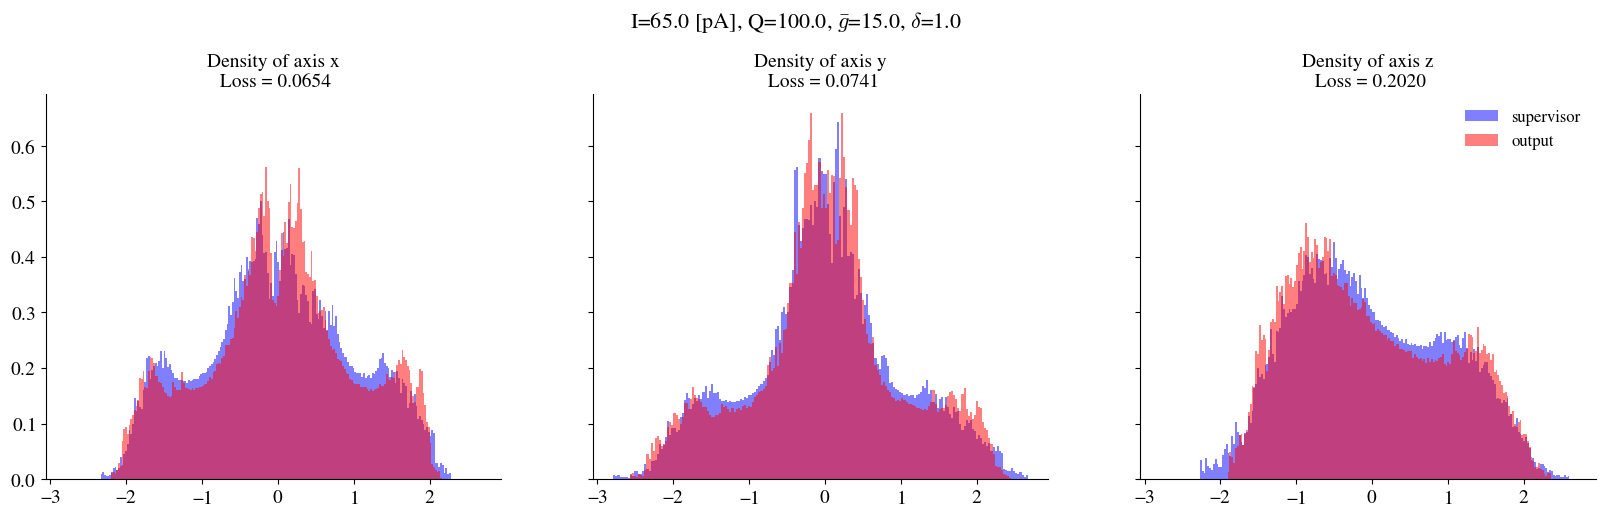

In [23]:
fig, ax = plt.subplots(figsize=(20, 5), ncols=len(hists), sharex=True, sharey=True)

ax_names = ['x', 'y', 'z']

for axis in range(len(ax)):
    bins = hists[axis][2]
    sup_hist = hists[axis][0]
    output_hist = hists[axis][1]
    # bins = (bins[:-1] + bins[1:]) / 2   # center of the bins
    width = bins[1] - bins[0]
    alpha = .5
    ax[axis].bar(bins[:-1], sup_hist, width=width, label="supervisor", color='b', alpha=alpha)
    ax[axis].bar(bins[:-1], output_hist, width=width, label="output", color='r', alpha=alpha)
    ax[axis].set_title(f"Density of axis {ax_names[axis]}\n Loss = {kl_divs[axis]:.4f}")
ax[2].legend(loc='upper right', frameon=False)
plt.suptitle(r"I=%.1f [pA], Q=%.1f, $\bar{g}$=%.1f, $\delta$=%.1f" % (Ie, Q, gbar, delta), y=1.05)
# plt.savefig(os.path.join(save_path, f"N_{N}_ff_{ff_coeff}_histogram." + extension), dpi=300, bbox_inches='tight')
plt.show()
